<h1>Lesson 3. Classification: Credit worthiness from German bank</h1>

<img src="https://upload.wikimedia.org/wikipedia/commons/8/8e/Flag_map_of_Germany.svg" style="height:200px;">
  
  <p>In this exercise you will predict credit worthiness of custmers of a German bank (<a href="https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)">provided by Hans Hofmann from Univeristy of Hamburg</a>). The data we will be working with here is a reduced version of the full dataset.</p>
<p>The following features are available for the 1000-row dataset:</p>
<ul>
<li>Class: Credit worthiness (what you are trying to predict)</li>
<li>Duration: Duration of the credit (in months) </li>
<li>Amount: Amount of money asked for (in Deutche Marks (DM))</li>
<li>InstallmentRatePercentage: Installment rate in percentage of disposable income </li>
<li>ResidenceDuration: Number of years at current residence</li>
<li>Age: Person's age</li>
<li>NumberExistingCredits: Number of credit accounts</li>
<li>NumberPeopleMaintenance: Number of people being liable to provide maintenance for the credit</li>
<li>Telephone: Is there a phone number associated with the customer name?  </li>
<li>ForeignWorker: Is the person a foreign worker?</li>
<li>CheckingAccountStatus: Amount of money in the checking account (in DM)<ul>
<li>CheckingAccountStatus.lt.0</li>
<li>CheckingAccountStatus.0.to.200</li>
<li>CheckingAccountStatus.gt.200</li>
</ul></li>
<li>CreditHistory: Past credit history<ul>
<li>CreditHistory.ThisBank.AllPaid</li>
<li>CreditHistory.PaidDuly</li>
<li>CreditHistory.Delay</li>
<li>CreditHistory.Critical</li>
</ul></li>
</ul>

<p>This dataset is available in <a href="http://caret.r-forge.r-project.org/">'caret'</a> library. Let's load it and see how it looks:</p>

In [1]:
import pandas as pd

# loading the training and test dataset
credit_train = pd.read_csv('credit_train.csv')
credit_test = pd.read_csv('credit_test.csv')

credit_train.head()

,Class,Duration,Amount,InstallmentRatePercentage,ResidenceDuration,Age,NumberExistingCredits,NumberPeopleMaintenance,Telephone,ForeignWorker,CheckingAccountStatus.lt.0,CheckingAccountStatus.0.to.200,CheckingAccountStatus.gt.200,CreditHistory.ThisBank.AllPaid,CreditHistory.PaidDuly,CreditHistory.Delay,CreditHistory.Critical
0,Good,6,1169,4,4,67,2,1,0,1,1,0,0,0,0,0,1
1,Bad,48,5951,2,2,22,1,1,1,1,0,1,0,0,1,0,0
2,Good,12,2096,2,3,49,1,2,1,1,0,0,0,0,0,0,1
3,Good,36,9055,2,4,35,1,2,0,1,0,0,0,0,1,0,0
4,Good,24,2835,3,4,53,1,1,1,1,0,0,0,0,1,0,0


<h3>Q.0. Write code to display the count of null values in each column<h3>

In [2]:
# Command: 
print("!ASSUMPTION: \"df.isnull()\" returns nothing for the dataset, I'm assuming \"count of null values\" means count of values that are zero.\n\n")
null_count = [credit_train.isin([0]).sum(),credit_test.isin([0]).sum()]
# One sentance summary:
print("Null Value Counts: Training Set")
print(null_count[0])
print()
print("Null Values Counts: Testing Set")
print(null_count[1])

!ASSUMPTION: "df.isnull()" returns nothing for the dataset, I'm assuming "count of null values" means count of values that are zero.


Null Value Counts: Training Set
Class                               0
Duration                            0
Amount                              0
InstallmentRatePercentage           0
ResidenceDuration                   0
Age                                 0
NumberExistingCredits               0
NumberPeopleMaintenance             0
Telephone                         319
ForeignWorker                      31
CheckingAccountStatus.lt.0        585
CheckingAccountStatus.0.to.200    600
CheckingAccountStatus.gt.200      753
CreditHistory.ThisBank.AllPaid    768
CreditHistory.PaidDuly            370
CreditHistory.Delay               738
CreditHistory.Critical            581
dtype: int64

Null Values Counts: Testing Set
Class                               0
Duration                            0
Amount                              0
InstallmentRatePercentage  

<h3>Q.1. How does the distribution of credit amount look like? (Use a histogram plot to answer this question)</h3>

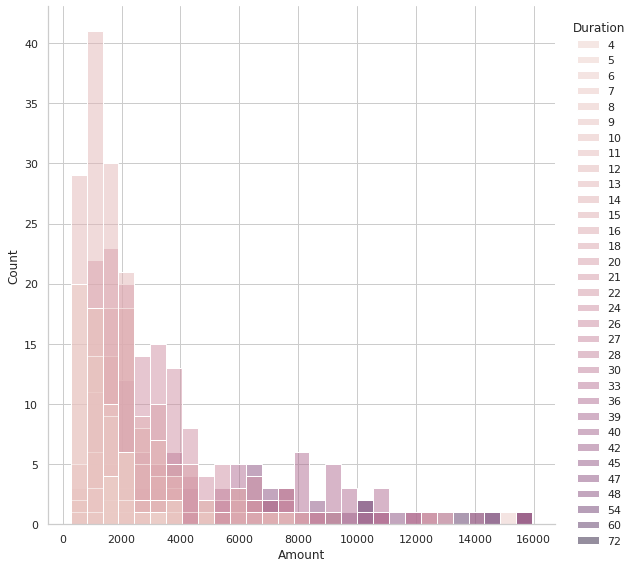

In [3]:
# Put the command (or commands) here that would give an answer to the above question.
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
sns.displot(credit_train, x=credit_train.Amount, hue ="Duration", height=8);
#TODO

#### The distribution for credit amount skews towards small amounts which makes sense from the stand point of the bank having a finite amount of capital for loaning out and they likely maximize profit by maximizing the number of loans.

<h3>Q.2. Can you generate a plot that shows CreditHistory.Critical vs. Credit Worthiness for the training data. Can you comment whether person with critical credit history is more credit worthy?</h3> 

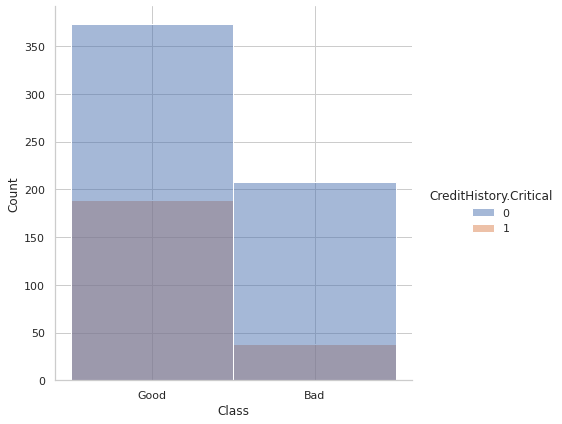

In [4]:
# Command:
sns.displot(credit_train, x="Class", hue="CreditHistory.Critical", height=6);

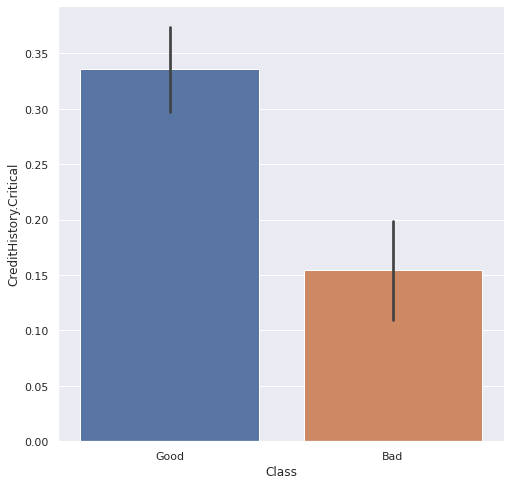

In [5]:
# Command:
sns.set(rc={'figure.figsize':(8,8)})
sns.barplot(data=credit_train, x="Class", y="CreditHistory.Critical");

#### It seems that individuals who have had credit history characterized as 'critical' are actually more likely to be credit worthy than those who don't.

<h3>Q.3. Binarize the y output for e.g. 0 = 'bad' credit; 1 = 'good' credit. </h3>

In [6]:
credit_train = credit_train.replace({"Class":{"Bad":0,"Good":1}})
credit_test = credit_test.replace({"Class":{"Bad":0,"Good":1}})

<h3>Q.4. Generate a logistic regression model that uses the one predictor CreditHistory.Critical. Provide a summary of the model. </h3>

In [7]:
from sklearn.linear_model import LogisticRegression
import numpy as np
X, y = np.asarray(credit_train.drop(columns="Class")), np.asarray(credit_train["Class"])
X_test, y_test = np.asarray(credit_test.drop(columns="Class")), np.asarray(credit_test["Class"])
clf = LogisticRegression(random_state=0,max_iter=700).fit(X, y) #max_iter < ~700 results in divergence

In [8]:
# "summary"
clf.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 700,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 0,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

<h3>Q.5. Using the developed model, predict the values in credit_test and use it to output a confusion matrix.</h3>

In [9]:
from sklearn.metrics import confusion_matrix
y_true, y_pred = y_test, clf.predict(X_test)
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))

confusion matrix:
 [[ 17  37]
 [ 21 117]]


<h3>Q.6. What is the accuracy of the model on the test data?</h3>

In [10]:
X_test, y_test = np.asarray(credit_test.drop(columns="Class")), np.asarray(credit_test["Class"])
# Command that outputs acccuracy
print("The mean accuracy score for this logistic regression model with the test data is {}%.".format(round(clf.score(X_test,y_test)*100,2)))

The mean accuracy score for this logistic regression model with the test data is 69.79%.


<h3>Q.7. Generate the ROC curve.</h3>

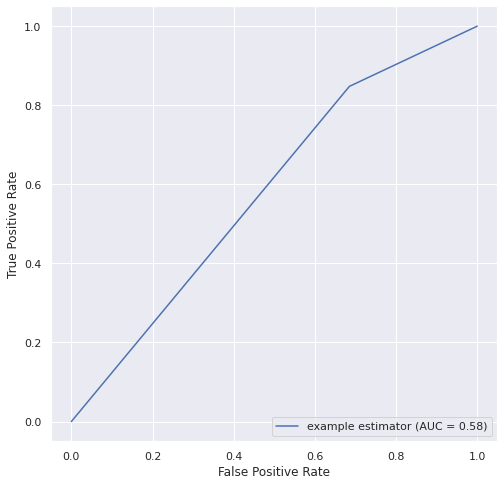

In [11]:
import matplotlib.pyplot as plt
from sklearn import metrics
fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='example estimator')
display.plot()

plt.show()

<h3>Q.8. What is the ROC AUC of the model on the test data?</h3>

In [12]:
# Command(s):
print("The ROC AUC for the model on the test dataset is {}.".format(round(roc_auc,4)))

The ROC AUC for the model on the test dataset is 0.5813.


<h3>Q.9. Calculate LDA model on credit_train.</h3>

In [13]:
from sklearn.decomposition import LatentDirichletAllocation
lda = LatentDirichletAllocation(n_components=5,random_state=0)
lda.fit(X);

<h3>Q.10. What is the accuracy of the new model?</h3>

In [14]:
print("The approximate log-likelihood \"score\" for this Latent Dirichlet Allocation model with the test data is {}.".format(round(lda.score(X_test),2)))
print("To my understanding, the approximate accuracy for this Latent Dirichlet Allocation model with the test data is ~{}%.".format(10**lda.score(X_test)))

The approximate log-likelihood "score" for this Latent Dirichlet Allocation model with the test data is -84336.25.
To my understanding, the approximate accuracy for this Latent Dirichlet Allocation model with the test data is 0.0%.


<h3>Q.11. Complete a 50-100 word summary of your experience in this assignment
  <br>  (or short description of your thinking in applying this week's learning to the solution) 

<br>Include:                                                                      
- What was your incoming experience with this model, if any?
- what steps you took, what obstacles you encountered.
- how you link this exercise to real-world, machine learning problem-solving. (What steps were missing? What else do you need to learn?)
- * This summary allows your instructor to know how you are doing and allot points for your effort in thinking and planning, and making connections to real-world work.

#### I actually had no experience with either model, or any like it before beginning this assignment which was unfortunate because I’ve been having to learn an incredible amount, and still have much to learn. Luckily I was able to use the scikit learn documentation to get a basic understanding of the two models, and how they’re applied to a dataset; because I haven’t managed to acquire the textbook yet but I needed to gain a conceptual understanding of the models, I utilized wikipedia as a resource and the pages for the two models are actually incredibly helpful and comprehensive. As for real-world applications, I think this classification modeling approach would be especially useful for particle physicists working with a dataset; often times the dataset requires the separation of signal from background noise, both signal & noise sources include resonant peaks from particle decays, nuclear interactions with detector materials, and photon conversions with detector material. I think this classification model could separate the data points that can be attributed to the particle of interest from those that are due to some background source. I’m sure this is already in use because it’s clearly applicable to that sort of situation.

#### One obstacle I encountered was the log-likelihood score for the LDA model, the values I'm getting have large magnitudes and are negative; I get similiar values when I do the same approach to an example sklearn dataset which leads me to believe these values are reasonable. It made me consider that these values are literally the log of the error score, and so when I raise 10 to the power of these values I get percentages that are essentially zero. I've intepretted this as an incredibly good level of accuracy achieved by the model but I am skeptical because any model with essentially zero error is unrealistic and automatically suspect.